<a href="https://colab.research.google.com/github/yelenana/machine_learning/blob/main/Rybchynska_Olena_%22HW_2_3_%D0%94%D0%B5%D1%80%D0%B5%D0%B2%D0%B0_%D0%BF%D1%80%D0%B8%D0%B9%D0%BD%D1%8F%D1%82%D1%82%D1%8F_%D1%80%D1%96%D1%88%D0%B5%D0%BD%D1%8C_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням Decision Trees і зробимо новий submission на змагання на Kaggle.

В цьому ДЗ ми працюємо без pipelines, бо так буде зручніше для візуалізації і інтерпретації моделі дерева прийняття рішень. Так буває і в робочих проєктах: іноді зручніше використати sklearn.Pipelines, іноді зручніше без них. На етапі пошуку рішення (research) зручніше без пайплайнів, а з пайплайнами - коли ви відлагодили процес обробки даних і хочете поекспериментувати з різними моделями і гіперпараметрами.

**Завдання 1.**

У попередньому домашньому завданні, `HW 2.7 Логістична регресія з scikit learn.ipynb`, ми писали обробку даних для змагання. Ваше завдання зараз - за прикладом, наведеним в лекції `Майстер-клас з перенесення коду з jupyter notebook у Python модуль`, перенести попередню обробку сирих даних з вашого розв'язку ДЗ 2.7 у файл `process_bank_churn.py` в функцію `preprocess_data(...)`.

Функція `preprocess_data()` має приймати `raw_df` і вертати `X_train`, `train_targets`, `X_val`, `val_targets`, `input_cols`(перелік назв колонок, які Ви використовуєте в X), `scaler`, `encoder`, які ми потім будемо використовувати для тренування дерева прийняття рішень.


### Кроки попередньої обробки:

1. Обираємо колонки для роботи. В цьому завдання для чистоти експериментів рекомендую прибрати колонку `Surname`, так буде простіше інтрепретувати модель. Ви можете її додати вже за самостійних подальших експериментів.
2. Розбиття сирих даних на тренувальні і валідаційні.
3. Обробка категоріальних даних (one hot encoding).
4. Масштабування числових даних (було частиною попередньої обробки в попередніх завданнях). Для дерев нам не обовʼязково масштабувати ознаки, тож в коді можна зробити цю частину опціональною, додавши в `preprocess_data` параметр `scaler_numeric`, який приймає значення `True` або `False`. Це дозволить використовувати код попередньоъ обробки з різними моделями.


### Інструкції:
1. Перенесіть попередню обробку даних у файл `process_bank_churn.py`.
2. Забезпечте модулярну структуру функцій: кожна функція повинна виконувати лише одну дію, наприклад, масштабувати ознаки.
3. Додайте докстрінги до кожної функції.
4. Використовуйте typing для аргументів та значень, що повертаються функціями.
5. Передбачте обробку нових даних. Додайте спеціальну функцію `preprocess_new_data(...)`, яка приймає на вхід нові дані в вигляді pandas DataFrame та використовує вже навчені скейлер та енкодер (передані теж як аргументи фукнціх) для їх обробки. Ця функція буде корисною для обробки нових даних перед передбаченням або оцінкою моделі, коли оброблятимемо `test.csv`.

Можна і рекомендовано виконувати це завдання з ChatGPT (бажано, новіше, ніж 3.5) як було наведено у відео-прикладі, тільки **ваше додаткове завдання - розібратись з кодом, який вам згенерувала мовна модель :)**.

## В результаті цього завдання

1. Завантажте ваш готовий `process_bank_churn.py` файл на GitHub у свій репозиторій.
2. Додайте посилання на файл в репозиторії тут у ноутбуці.
3. Нижче зробіть імпорт функції `preprocess_data` з вашого модуля `process_bank_churn.py`.



https://github.com/yelenana/machine_learning/blob/main/process_bank_churn.py

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import sys
import os

# Наприклад, шлях до вашої папки на диску
path_to_module = '/content/drive/MyDrive/ML/2_3'
sys.path.append(path_to_module)

from process_bank_churn import preprocess_data

**Завдання 2.**
1. Натренуйте дерево прийняття рішень з зафіксованим `random_state` і з рештою аргументів за замовченням.
2. Виведіть area under ROC для моделі на тренувальних і тестувальних даних. Нам потрібна ця метрика, бо вона основна в змаганні. Модель ок, чи є пере- або недотренування?
3. Виведіть глибину дерева.
4. Побудуйте дерево до глибини 2 включно. Напишіть, які ознаки бачите, що є найвпливовішими тут?
5. Створіть датафрейм `importance_df` з feature importances, де в першому стовпчику `feature` - назва ознаки з нашого Х, а в другому `importance` - значення, наскільки ця ознака є важливою в побудованій моделі. Виведіть топ 10 найвпливовіших ознак разом з їх скором важливості (можна або у вигляді таблиці, або в вигляді barplot).

2.1.

In [3]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score

In [4]:
!ls drive/MyDrive/ML/2_3/

Churn_Modelling.csv    __pycache__	      test.csv
process_bank_churn.py  sample_submission.csv  train.csv


In [5]:
raw_df = pd.read_csv("drive/MyDrive/ML/2_3/Churn_Modelling.csv")
raw_df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
data = preprocess_data(raw_df)

In [7]:
X_train = data['X_train']
train_targets = data['train_targets']
X_val = data ['X_val']
val_targets = data['val_targets']


In [8]:
model = DecisionTreeClassifier(random_state=42)

In [9]:
%%time
model.fit(X_train, train_targets)


CPU times: user 95.1 ms, sys: 891 µs, total: 96 ms
Wall time: 98.4 ms


DecisionTreeClassifier(random_state=42)

2.2.

In [10]:
# Get predictions (probabilities for the positive class)
train_probs = model.predict_proba(X_train)[:, 1]
val_probs = model.predict_proba(X_val)[:, 1]

# Calculate ROC AUC scores
train_auc = roc_auc_score(train_targets, train_probs)
val_auc = roc_auc_score(val_targets, val_probs)

print(f"Train ROC AUC: {train_auc:.4f}")
print(f"Validation ROC AUC: {val_auc:.4f}")

Train ROC AUC: 1.0000
Validation ROC AUC: 0.6969


Так як train_auc близький до 1.0, а val_auc значно нижчий (наприклад, 0.7), то модель перенавчена (overfitting).

2.3.

In [11]:
print(f"Tree Depth: {model.get_depth()}")

Tree Depth: 24


2.4.

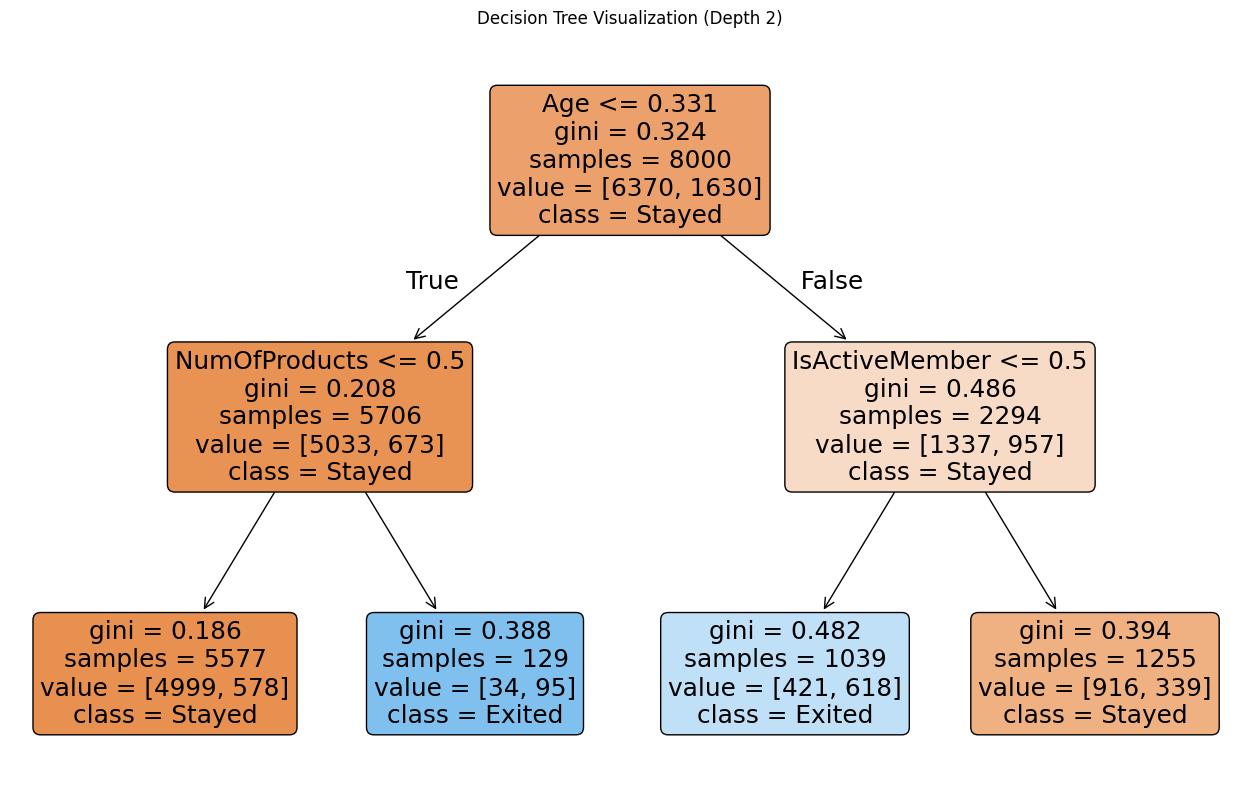

In [12]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Train a simplified model for visualization
model_small = DecisionTreeClassifier(max_depth=2, random_state=42)
model_small.fit(X_train, train_targets)

# Visualize the tree structure
plt.figure(figsize=(16, 10))
plot_tree(
    model_small,
    feature_names=list(X_train.columns),
    filled=True,
    rounded=True,
    class_names=['Stayed', 'Exited']
)
plt.title("Decision Tree Visualization (Depth 2)")
plt.show()

Дивлячись на дерево глибиною 2, ми бачимо, що  найважливіші ознаки:

Age (Вік): Це найголовніша ознака (корінь дерева). Перший поділ відбувається саме за віком. Якщо масштабований вік клієнта $\le 0.331$, він з більшою ймовірністю залишиться (Stayed).

NumOfProducts (Кількість продуктів): Для молодших клієнтів це другий за важливістю фактор.

IsActiveMember (Активність): Для старших клієнтів критичним фактором є те, чи є вони активними членами банку.

2.5


Top 10 Most Influential Features:
              feature  importance
1                 Age    0.227109
3             Balance    0.155108
7     EstimatedSalary    0.151537
0         CreditScore    0.139731
4       NumOfProducts    0.117425
2              Tenure    0.072249
6      IsActiveMember    0.057017
9   Geography_Germany    0.021673
5           HasCrCard    0.015771
12        Gender_Male    0.015698


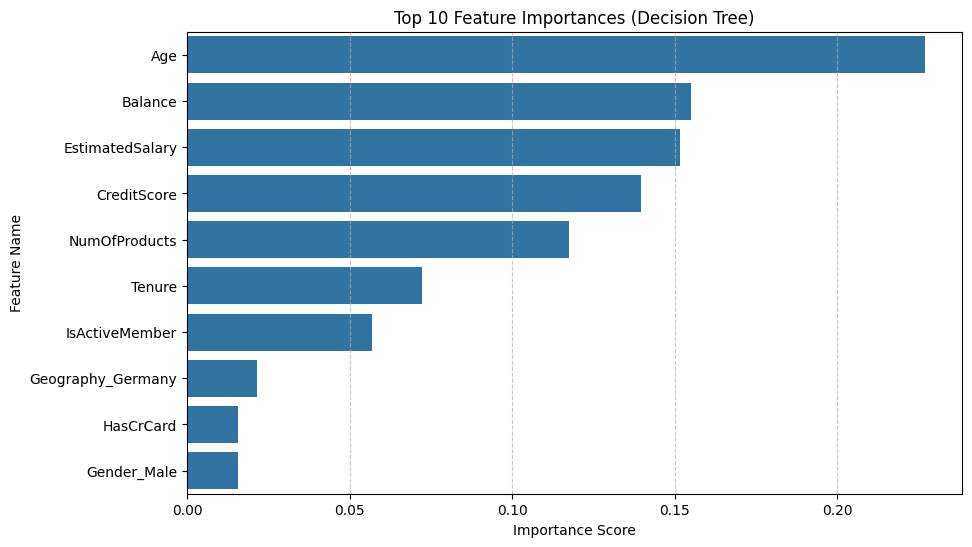

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a DataFrame with feature names and their importance scores
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

# 2. Display the Top 10 most influential features
print("Top 10 Most Influential Features:")
print(importance_df.head(10))

# 3. Visualize the Top 10 features using a barplot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df.head(10),
    x='importance',
    y='feature'
)
plt.title('Top 10 Feature Importances (Decision Tree)')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**Виходячи  з отриманого результату, висновок наступний:**

* Age (Вік): найвище значення ($> 0.20$). Це означає, що вік є найсильнішим

індикатором того, чи залишиться клієнт у банку.

* Balance (Баланс) та EstimatedSalary (Очікувана зарплата): Фінансові показники мають велику вагу, що логічно для банківської сфери.

* CreditScore (Кредитний рейтинг) та NumOfProducts (Кількість продуктів): Також входять у п'ятірку найважливіших.

**Завдання 3**. Спробуйте знайти такі параметри моделі `DecisionTree` аби модель генералізувала ліпше (був вищий показник AUROC на валідаційній вибірці). Проекспериментуйте з різними значеннями параметрів `max_leaf_nodes`, `max_depth` та лишіть ті, які дають найкращий результат, разом з відповідними AUROC на тренувальній і валідаційній вибірках.

В цьому завданні спробуйте просто знайти параметри методом "тика" :)

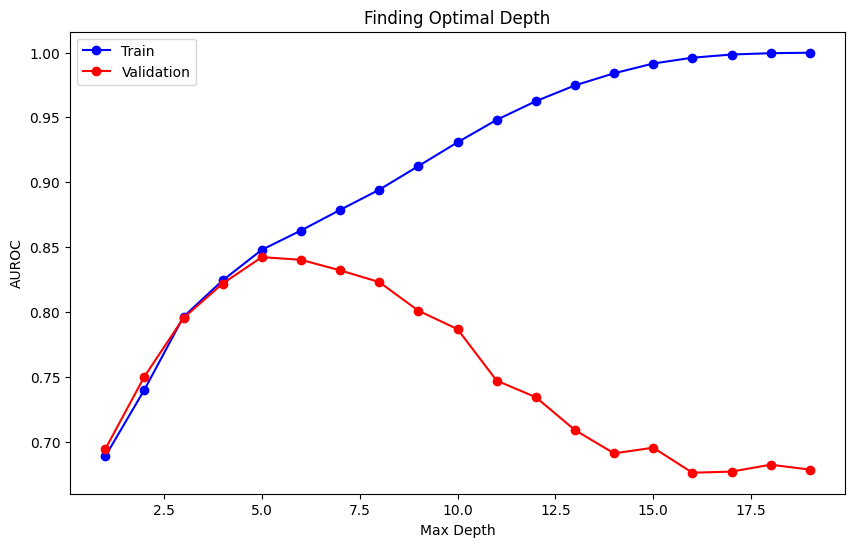

In [14]:
depths = range(1, 20)
train_aucs, val_aucs = [], []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, train_targets)
    train_aucs.append(roc_auc_score(train_targets, model.predict_proba(X_train)[:, 1]))
    val_aucs.append(roc_auc_score(val_targets, model.predict_proba(X_val)[:, 1]))

plt.figure(figsize=(10, 6))
plt.plot(depths, train_aucs, 'b-o', label='Train')
plt.plot(depths, val_aucs, 'r-o', label='Validation')
plt.title('Finding Optimal Depth')
plt.xlabel('Max Depth')
plt.ylabel('AUROC')
plt.legend()
plt.show()

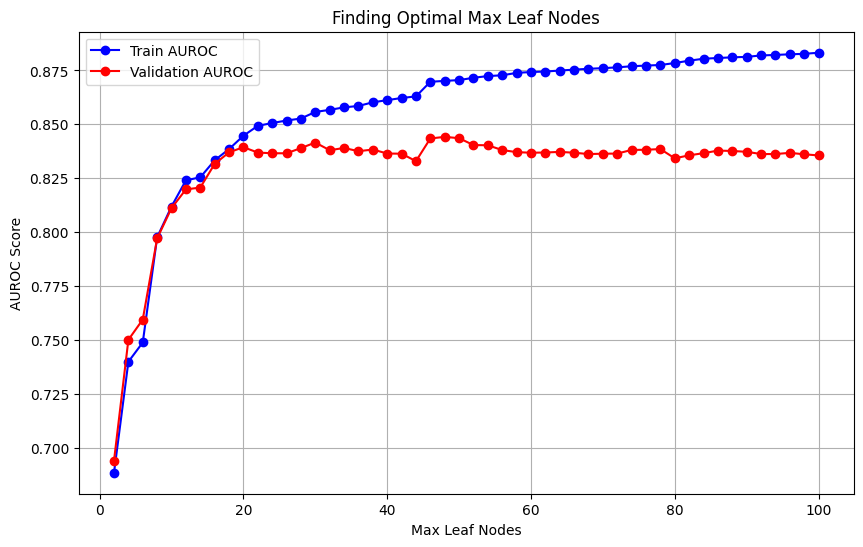

In [15]:
leaf_nodes = range(2, 101, 2) # Testing from 2 to 100 nodes
train_aucs, val_aucs = [], []

for n in leaf_nodes:
    model = DecisionTreeClassifier(max_leaf_nodes=n, random_state=42)
    model.fit(X_train, train_targets)

    train_aucs.append(roc_auc_score(train_targets, model.predict_proba(X_train)[:, 1]))
    val_aucs.append(roc_auc_score(val_targets, model.predict_proba(X_val)[:, 1]))

plt.figure(figsize=(10, 6))
plt.plot(leaf_nodes, train_aucs, 'b-o', label='Train AUROC')
plt.plot(leaf_nodes, val_aucs, 'r-o', label='Validation AUROC')
plt.title('Finding Optimal Max Leaf Nodes')
plt.xlabel('Max Leaf Nodes')
plt.ylabel('AUROC Score')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
def evaluate_model(max_depth: int = None, max_leaf_nodes: int = None):
    """
    Helper function to train and evaluate DecisionTreeClassifier
    """
    # 1. Initialize and train the model
    model = DecisionTreeClassifier(
        max_depth=max_depth,
        max_leaf_nodes=max_leaf_nodes,
        random_state=42
    )
    model.fit(X_train, train_targets)

    # 2. Get AUROC scores
    train_auc = roc_auc_score(train_targets, model.predict_proba(X_train)[:, 1])
    val_auc = roc_auc_score(val_targets, model.predict_proba(X_val)[:, 1])

    print(f"Parameters: max_depth={max_depth}, max_leaf_nodes={max_leaf_nodes}")
    print(f"Train AUROC: {train_auc:.4f} | Validation AUROC: {val_auc:.4f}")
    print(f"Difference (Gap): {abs(train_auc - val_auc):.4f}")
    print("-" * 60)

    return val_auc

# --- Let's experiment! ---

# 1. Start with a deep tree (Overfitting example)
evaluate_model(max_depth=20, max_leaf_nodes=None)

# 2. Try limiting depth
evaluate_model(max_depth=5, max_leaf_nodes=None)
evaluate_model(max_depth=7, max_leaf_nodes=None)

# 3. Try limiting leaf nodes
evaluate_model(max_depth=None, max_leaf_nodes=20)
evaluate_model(max_depth=None, max_leaf_nodes=50)

# 4. Try a combination (The "Sweet Spot")
evaluate_model(max_depth=5, max_leaf_nodes=20)

# 5. Try a combination
evaluate_model(max_depth=5, max_leaf_nodes=25)

# 6. Try a combination
evaluate_model(max_depth=5, max_leaf_nodes=43)

Parameters: max_depth=20, max_leaf_nodes=None
Train AUROC: 1.0000 | Validation AUROC: 0.6899
Difference (Gap): 0.3101
------------------------------------------------------------
Parameters: max_depth=5, max_leaf_nodes=None
Train AUROC: 0.8479 | Validation AUROC: 0.8423
Difference (Gap): 0.0057
------------------------------------------------------------
Parameters: max_depth=7, max_leaf_nodes=None
Train AUROC: 0.8787 | Validation AUROC: 0.8321
Difference (Gap): 0.0466
------------------------------------------------------------
Parameters: max_depth=None, max_leaf_nodes=20
Train AUROC: 0.8447 | Validation AUROC: 0.8394
Difference (Gap): 0.0053
------------------------------------------------------------
Parameters: max_depth=None, max_leaf_nodes=50
Train AUROC: 0.8705 | Validation AUROC: 0.8436
Difference (Gap): 0.0269
------------------------------------------------------------
Parameters: max_depth=5, max_leaf_nodes=20
Train AUROC: 0.8457 | Validation AUROC: 0.8452
Difference (Gap):

np.float64(0.8422536558129778)

В результаті аналізу графіків залежностей Train AUROC/Validation AUROC від Max Depth та Max Leaf Nodes, а потім перебору результатів оцінки точності моделі в залежності від цих двох параметрів, я отримала результат, що max_depth=5, max_leaf_nodes=20 - дає найкращий результат

**Завдання 4**. В циклі пройдіться по значенням max_depth від 1 до 20 включно, на кожній ітерації натренуйте DecisionTree модель і виміряйте AUROC на трейн і валідаційних даних.

В кінці виведіть на графік залеєність між AUROC на трейн і валідаційних даних і номером ітерації.

***Це вже було зроблено у попередньому завданні для пошуку оптимального значення max_depth для даної моделі  DecisionTree***

**Завдання 5**.
1. Натренуйте модель `DecisionTree` з найкращим значенням `max_depth`, яке ви знайшли на попередній ітерації.
2. Завантажте тестові дані змагання з `test.csv`.
3. Зробіть попередню обробку даних з функцією `preprocess_new_data` з вашого модуля `process_bank_churn.py`.
4. Зробіть передбачення використовуючи цю модель на тестових даних змагання.
5. Сформуйте `submission.csv`.
6. Зробіть новий Submission на Kaggle і додайте тут скріншот Вашого скору на паблік лідерборді :)


In [17]:
final_model = DecisionTreeClassifier(
    max_depth=5,
    max_leaf_nodes=20,
    random_state=42
)

In [18]:
final_model.fit(X_train, train_targets)

DecisionTreeClassifier(max_depth=5, max_leaf_nodes=20, random_state=42)

In [19]:
test_raw_df = pd.read_csv("drive/MyDrive/ML/2_3/test.csv")

In [20]:
test_raw_df.head(3)

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45


In [36]:
from process_bank_churn import preprocess_new_data
X_test = preprocess_new_data(
    test_raw_df,
    input_cols=data['input_cols'],
    scaler=data['scaler'],
    encoder=data['encoder']
)

In [37]:
test_probs = final_model.predict_proba(X_test)[:, 1]

In [38]:
test_probs

array([0.3135436 , 0.0202952 , 0.18473896, ..., 0.0202952 , 0.09986945,
       0.22644928])

In [39]:
test_preds = final_model.predict(X_test)

In [40]:
test_preds

array([0, 0, 0, ..., 0, 0, 0])

In [41]:
submission_file_path = 'drive/MyDrive/ML/2_3/sample_submission.csv'
submission = pd.read_csv(submission_file_path)
submission['Exited']=test_probs
submission.head()

,id,Exited
0,15000,0.313544
1,15001,0.020295
2,15002,0.184739
3,15003,0.265432
4,15004,0.039735


In [42]:
output_filename = 'drive/MyDrive/ML/2_3/submission_log_reg.csv'
submission.to_csv(output_filename, index=False)

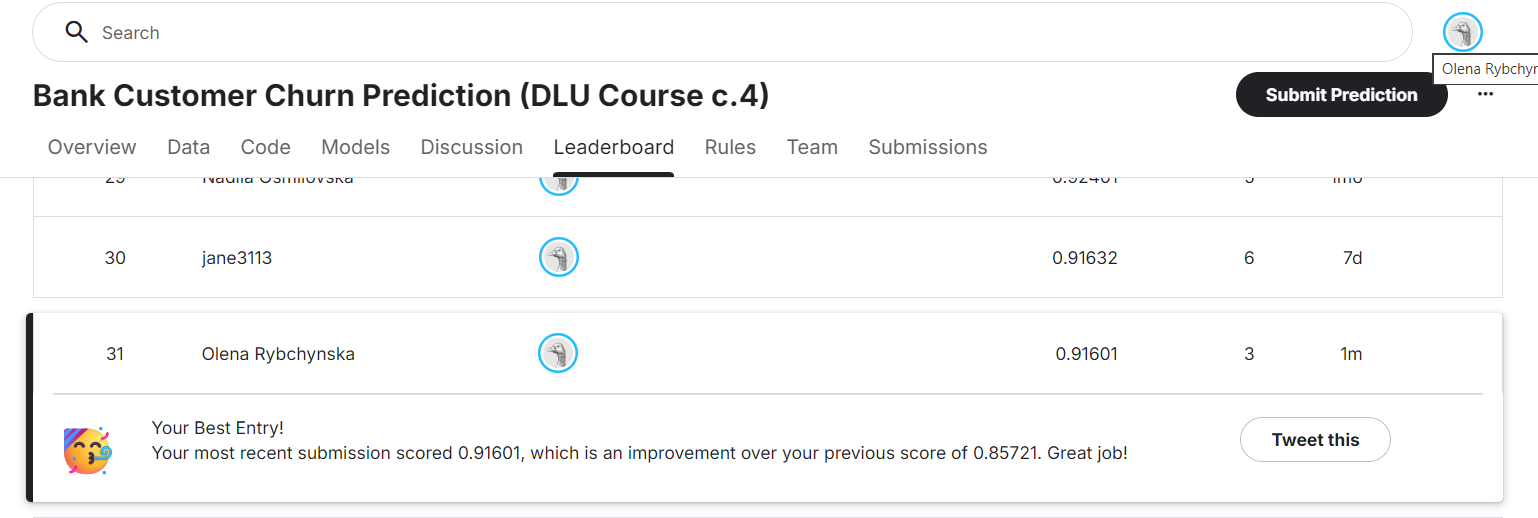